# Exploratory Data Analysis: Predicting restaurant business survival

## 1. Business Understanding
**Problem Statement:**
The restaurant industry experiences high failure rates, with many businesses closing within their first few years. This project aims to develop a machine learning model that predicts whether a restaurant will remain open or close using features from the Yelp dataset, including customer reviews, ratings, and location-based factors.

**Key Business Questions:**

- What factors most influence whether a restaurant survives or closes?
- How do customer ratings and reviews impact restaurant longevity?
- Does location or nearby competition affect survival rates?
- Can we identify early warning signs that a restaurant is at risk of closing?
- How can businesses use this information to improve their chances of success?

**Business Objectives:**

- Build a predictive model to classify restaurants as open (surviving) or closed (failed)
- Identify the most important features that drive restaurant success or failure
- Provide actionable insights for restaurant owners and stakeholders
- Improve decision-making using data-driven predictions

**Success Criteria:**
- Achieve strong model performance (e.g., high ROC-AUC, precision, and recall)
- Correctly identify a high proportion of restaurants that are at risk of closing
- Generate interpretable insights about key survival factors
- Ensure the model generalizes well to unseen data

## 2. Data Understanding

The dataset consists of Yelp business data, including:

- Business attributes (category, location, price range)
- Customer reviews and ratings
- Operational status (is_open)
- Geographic and competitive information

The dataset was very large because it is a publicly available dataset that is continuously updated, so we selected a sample of 20,000 records for analysis.

### 2.1 Data dictionary

| Column Name      | Data Type          | Description                                           |
| ---------------- | ------------------ | ----------------------------------------------------- |
| `review_id`      | Object (string)    | Unique identifier for each review                     |
| `user_id`        | Object (string)    | Unique identifier for the user who wrote the review   |
| `business_id`    | Object (string)    | Unique identifier for the restaurant/business         |
| `review_stars`   | Float              | Rating given by the user (e.g., 1–5 stars)            |
| `useful`         | Integer            | Number of users who marked the review as useful       |
| `funny`          | Integer            | Number of users who marked the review as funny        |
| `cool`           | Integer            | Number of users who marked the review as cool         |
| `text`           | Object (string)    | Full text of the review                               |
| `date`           | Object (string)    | Date the review was posted                            |
| `name`           | Object (string)    | Name of the restaurant/business                       |
| `address`        | Object (string)    | Street address of the business                        |
| `city`           | Object (string)    | City where the business is located                    |
| `state`          | Object (string)    | State abbreviation                                    |
| `postal_code`    | Object (string)    | ZIP/postal code                                       |
| `latitude`       | Float              | Geographic latitude of the business                   |
| `longitude`      | Float              | Geographic longitude of the business                  |
| `business_stars` | Float              | Average rating of the business                        |
| `review_count`   | Integer            | Total number of reviews for the business              |
| `is_open`        | Integer (0/1)      | Whether the business is open (1 = open, 0 = closed)   |
| `attributes`     | Object (JSON-like) | Business features (e.g., OutdoorSeating, GoodForKids) |
| `categories`     | Object (string)    | Business categories (e.g., Restaurants, Pizza)        |
| `hours`          | Object (JSON-like) | Business operating hours                              |


### 2.2 Dataset Sizes

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler


In [105]:
from google.colab import drive

drive.mount('/content/drive')

path = '/content/drive/MyDrive/ML/Project/restaurants_dataset.csv'

df = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
print("Restaurant Shape:", df.shape)
df.head()

Restaurant Shape: (20000, 22)


,review_id,user_id,business_id,review_stars,useful,funny,cool,text,date,name,...,state,postal_code,latitude,longitude,business_stars,review_count,is_open,attributes,categories,hours
0,7BXtAgGXenuDJgngFRecyA,vr-Rw3nMKIgGrVNT6A7p9g,Ipkx4Sa7ybn8C6LtTqTztw,4.0,3,0,1,"Here is the deal, in the morning, as early as ...",2016-03-08 20:11:17,Double Knot,...,PA,19107,39.949699,-75.162185,4.5,1140,1,"{'GoodForDancing': 'False', 'Caters': 'True', ...","Nightlife, Sushi Bars, Cafes, Japanese, Bars, ...","{'Monday': '16:0-22:0', 'Tuesday': '16:0-22:0'..."
1,0UFCKBCNlLyHvZoHRDAAqw,3l4I__FvMFrYKUrPQhvGwQ,cNua7EAP7aoHTEp734VqWA,5.0,0,0,0,Excellent resteraunt. Food was very good and c...,2019-01-27 19:23:37,Hên Vietnamese Eatery,...,NJ,08003,39.896071,-74.949167,4.5,192,1,"{'BusinessAcceptsCreditCards': 'True', 'NoiseL...","Vietnamese, Soup, Sandwiches, Restaurants","{'Monday': '0:0-0:0', 'Tuesday': '11:30-20:0',..."
2,K4wVCHTOSC3f28zI_CI2kw,1s_M2Q5NYOpOt_nqn_Pcmw,LLSCjPWE0iBKogY301vsKw,3.0,1,0,0,The service was fantastic. Very homey place. ...,2015-11-07 02:44:51,Gourmet Seafood & Grill,...,PA,19473,40.227668,-75.404260,3.5,16,0,"{'WiFi': ""u'free'"", 'BusinessAcceptsCreditCard...","Food, Bakeries, Mediterranean, Restaurants, Se...","{'Monday': '16:0-23:0', 'Tuesday': '12:0-1:0',..."
3,9jfXG0Mr2YaLmYK162je7Q,hZE4LEa_wb1J2ErAPYN0uQ,Ps7Q7BOKzJO4nDTUhbk43Q,5.0,0,0,0,"Fabulous seafood, creative menu, indoor and ou...",2019-04-23 22:33:19,Clear Sky Cafe,...,FL,33767,27.981960,-82.827297,4.5,1824,1,"{'OutdoorSeating': 'True', 'Alcohol': ""u'full_...","Restaurants, American (Traditional), Tapas/Sma...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ..."
4,wukrbOHww7F5RZgCI5t_Gg,2BolkZ_JvR-1NZ0ro-qE4w,qtg5d6UmDVFeUw5ZKVBl4Q,3.0,0,0,0,Really friendly staff! Very attentive. Food wa...,2016-08-15 00:57:41,Coffee House Too,...,PA,19125,39.976728,-75.123718,4.5,246,1,"{'NoiseLevel': ""u'average'"", 'Ambience': ""{'ro...","Food, Coffee & Tea, Restaurants, Breakfast & B...","{'Monday': '0:0-0:0', 'Tuesday': '7:0-14:0', '..."


## 3. Data Preperation

### 3.1 Data Inspection

3.1.1 Check missing values

In [107]:
# Missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)


Missing values:
 review_id           0
user_id             0
business_id         0
review_stars        0
useful              0
funny               0
cool                0
text                0
date                0
name                0
address            42
city                0
state               0
postal_code         3
latitude            0
longitude           0
business_stars      0
review_count        0
is_open             0
attributes         23
categories          0
hours             707
dtype: int64


3.1.2 Check duplicate values

In [108]:
# Duplicate users
duplicates = df['business_id'].duplicated().sum()
print("Duplicate Business:", duplicates)

Duplicate Business: 8054


**Key Observation:**

- Most features contain no missing values, indicating overall strong data quality
- Minor missing values in:
    - postal_code (3 missing) – negligible impact
    - address (42) minor impact on location-based analysis.
    - attributes (23 missing) – may affect feature engineering.
    - hours (707 missing) – significant and may indicate incomplete business information
- There are 8,054 duplicate business entries.
  - This likely occurs because multiple reviews are associated with the same business
  - Important to aggregate at business level when needed to avoid treating each row as a unique business.
- Mixed data types:
  - Structured (ratings, counts)
  - Unstructured (text)
  - Semi-structured (attributes, hours)

### 3.2 Data Cleaning

3.2.1 Standardized Column Names

In [109]:
df.columns = df.columns.str.strip().str.lower()
print("Standardized column names:",df.columns)


Standardized column names: Index(['review_id', 'user_id', 'business_id', 'review_stars', 'useful',
       'funny', 'cool', 'text', 'date', 'name', 'address', 'city', 'state',
       'postal_code', 'latitude', 'longitude', 'business_stars',
       'review_count', 'is_open', 'attributes', 'categories', 'hours'],
      dtype='object')


3.2.2 Handling Missing Data

In [110]:
df["address"] = df["address"].fillna("Unknown")
df["postal_code"] = df["postal_code"].fillna("Unknown")


df["attributes"] = df["attributes"].fillna("{}")
df["hours"] = df["hours"].fillna("{}")

print("\nMissing values after cleaning:\n")
print(df.isnull().sum())

df.head()


Missing values after cleaning:

review_id         0
user_id           0
business_id       0
review_stars      0
useful            0
funny             0
cool              0
text              0
date              0
name              0
address           0
city              0
state             0
postal_code       0
latitude          0
longitude         0
business_stars    0
review_count      0
is_open           0
attributes        0
categories        0
hours             0
dtype: int64


,review_id,user_id,business_id,review_stars,useful,funny,cool,text,date,name,...,state,postal_code,latitude,longitude,business_stars,review_count,is_open,attributes,categories,hours
0,7BXtAgGXenuDJgngFRecyA,vr-Rw3nMKIgGrVNT6A7p9g,Ipkx4Sa7ybn8C6LtTqTztw,4.0,3,0,1,"Here is the deal, in the morning, as early as ...",2016-03-08 20:11:17,Double Knot,...,PA,19107,39.949699,-75.162185,4.5,1140,1,"{'GoodForDancing': 'False', 'Caters': 'True', ...","Nightlife, Sushi Bars, Cafes, Japanese, Bars, ...","{'Monday': '16:0-22:0', 'Tuesday': '16:0-22:0'..."
1,0UFCKBCNlLyHvZoHRDAAqw,3l4I__FvMFrYKUrPQhvGwQ,cNua7EAP7aoHTEp734VqWA,5.0,0,0,0,Excellent resteraunt. Food was very good and c...,2019-01-27 19:23:37,Hên Vietnamese Eatery,...,NJ,08003,39.896071,-74.949167,4.5,192,1,"{'BusinessAcceptsCreditCards': 'True', 'NoiseL...","Vietnamese, Soup, Sandwiches, Restaurants","{'Monday': '0:0-0:0', 'Tuesday': '11:30-20:0',..."
2,K4wVCHTOSC3f28zI_CI2kw,1s_M2Q5NYOpOt_nqn_Pcmw,LLSCjPWE0iBKogY301vsKw,3.0,1,0,0,The service was fantastic. Very homey place. ...,2015-11-07 02:44:51,Gourmet Seafood & Grill,...,PA,19473,40.227668,-75.404260,3.5,16,0,"{'WiFi': ""u'free'"", 'BusinessAcceptsCreditCard...","Food, Bakeries, Mediterranean, Restaurants, Se...","{'Monday': '16:0-23:0', 'Tuesday': '12:0-1:0',..."
3,9jfXG0Mr2YaLmYK162je7Q,hZE4LEa_wb1J2ErAPYN0uQ,Ps7Q7BOKzJO4nDTUhbk43Q,5.0,0,0,0,"Fabulous seafood, creative menu, indoor and ou...",2019-04-23 22:33:19,Clear Sky Cafe,...,FL,33767,27.981960,-82.827297,4.5,1824,1,"{'OutdoorSeating': 'True', 'Alcohol': ""u'full_...","Restaurants, American (Traditional), Tapas/Sma...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ..."
4,wukrbOHww7F5RZgCI5t_Gg,2BolkZ_JvR-1NZ0ro-qE4w,qtg5d6UmDVFeUw5ZKVBl4Q,3.0,0,0,0,Really friendly staff! Very attentive. Food wa...,2016-08-15 00:57:41,Coffee House Too,...,PA,19125,39.976728,-75.123718,4.5,246,1,"{'NoiseLevel': ""u'average'"", 'Ambience': ""{'ro...","Food, Coffee & Tea, Restaurants, Breakfast & B...","{'Monday': '0:0-0:0', 'Tuesday': '7:0-14:0', '..."


3.2.3 Remove exact duplicate rows

In [111]:
df = df.drop_duplicates(subset="business_id")
print("\nShape after removing exact duplicates:", df.shape)


Shape after removing exact duplicates: (11946, 22)


3.2.4 Convert date column

In [112]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

3.2.5 Clean text column

In [113]:
df["text"] = (
    df["text"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

In [114]:
print("\nCleaned shape:", df.shape)
df.to_csv("cleaned_dataset.csv", index=False)


Cleaned shape: (11946, 22)


### 3.3 Target Variable

In [115]:
path2 = '/content/drive/MyDrive/ML/Project/cleaned_dataset.csv'

df = pd.read_csv(path2)

In [116]:
df["target"] = df["is_open"]  # 1 = Open, 0 = Closed

### 3.4 Feature Engineering

3.4.1 Basic Features

In [117]:
basic_features = ["review_stars", "review_count", "city", "state", "postal_code"]

3.4.2 Business attributes

In [118]:
def parse_attributes(attr):
    if pd.isna(attr):
        return {}
    if isinstance(attr, str):
        try:
            return ast.literal_eval(attr)
        except:
            return {}
    return attr

df["attributes"] = df["attributes"].apply(parse_attributes)

df["OutdoorSeating"] = df["attributes"].apply(lambda x: x.get("OutdoorSeating", "False") == "True")
df["GoodForKids"] = df["attributes"].apply(lambda x: x.get("GoodForKids", "False") == "True")

df["PriceRange"] = df["attributes"].apply(lambda x: x.get("RestaurantsPriceRange2", np.nan))
df["PriceRange"] = pd.to_numeric(df["PriceRange"], errors="coerce")


3.4.3 Review-based features

In [119]:
df["log_review_count"] = np.log1p(df["review_count"])

3.4.4 Location-based features

In [120]:
city_counts = df["city"].value_counts()
df["restaurant_density_city"] = df["city"].map(city_counts)

df["categories"] = df["categories"].fillna("")

def has_category(cat_string, keyword):
    return keyword.lower() in cat_string.lower()

### 3.5 Data Transformation

3.5.1 Encoding Categorical Variables

In [121]:
df = pd.get_dummies(df, columns=["city", "state"], drop_first=True)

3.5.2 Feature Scaling

In [122]:
scaler = StandardScaler()
numeric_cols = ["review_stars", "review_count", "log_review_count", "restaurant_density_city", "PriceRange"]

df[numeric_cols] = scaler.fit_transform(df[numeric_cols].fillna(0))


3.5.3  Final Model Dataset

In [123]:
feature_cols = [
    "review_stars",
    "review_count",
    "log_review_count",
    "restaurant_density_city",
    "PriceRange",
    "OutdoorSeating",
    "GoodForKids"
] + [col for col in df.columns if col.startswith("city_") or col.startswith("state_")]

X = df[feature_cols]
y = df["target"]

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (11911, 564)
Target distribution:
 target
1    8996
0    2915
Name: count, dtype: int64


In [124]:
model_df = X.copy()
model_df["target"] = y

# -------------------------------
# Save to CSV
# -------------------------------
model_df.to_csv("model_dataset.csv", index=False)

print("✅ model_dataset.csv saved successfully!")
print("Shape:", model_df.shape)

✅ model_dataset.csv saved successfully!
Shape: (11911, 565)


In [125]:
path3 = '/content/drive/MyDrive/ML/Project/model_dataset.csv'

df = pd.read_csv(path3)

### 3.6 Feature Selection

3.6.1 Visualizations

Target Variable Distribution:
target
1    8996
0    2915
Name: count, dtype: int64
target
1    0.755268
0    0.244732
Name: proportion, dtype: float64


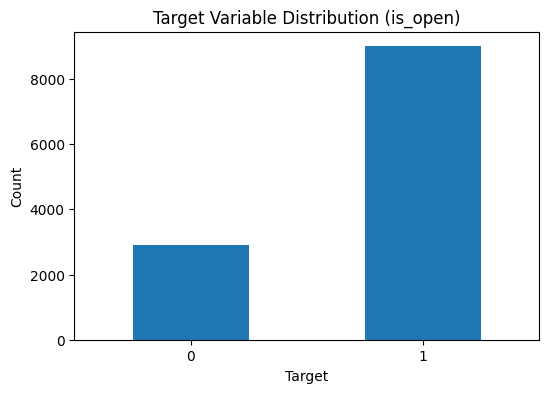

In [126]:
print("Target Variable Distribution:")
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
df['target'].value_counts().sort_index().plot(kind='bar')
plt.title("Target Variable Distribution (is_open)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

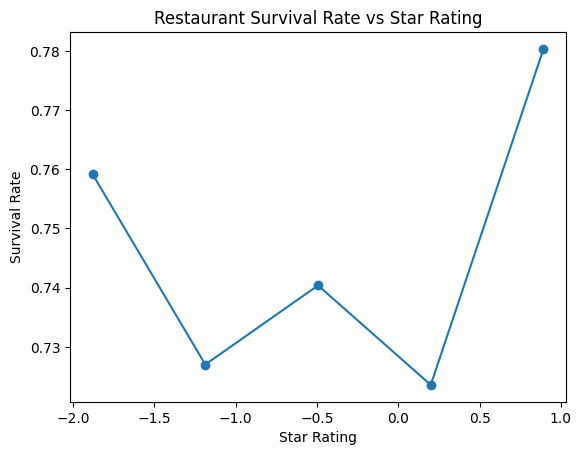

In [127]:
plt.figure()
df.groupby("review_stars")["target"].mean().plot(kind="line", marker='o')
plt.title("Restaurant Survival Rate vs Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Survival Rate")
plt.show()

/tmp/ipykernel_8906/1480721860.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("review_count_bins")["target"].mean().plot(kind="bar")


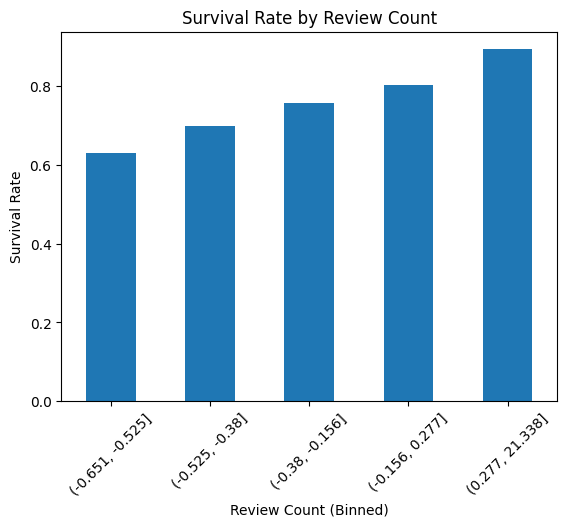

In [128]:
plt.figure()
df["review_count_bins"] = pd.qcut(df["review_count"], q=5)

df.groupby("review_count_bins")["target"].mean().plot(kind="bar")
plt.title("Survival Rate by Review Count")
plt.xlabel("Review Count (Binned)")
plt.ylabel("Survival Rate")
plt.xticks(rotation=45)
plt.show()

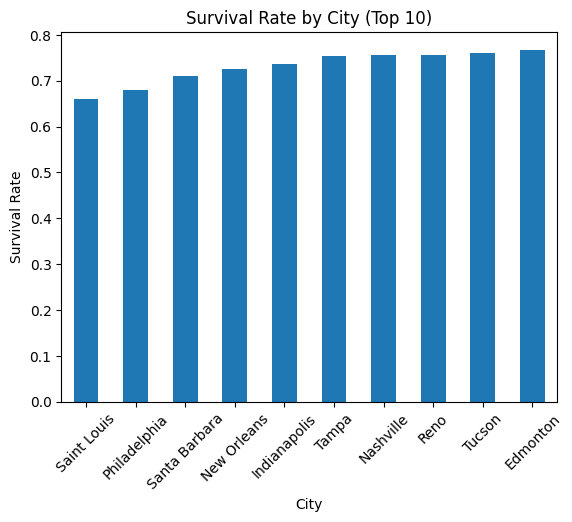

In [129]:
city_cols = [col for col in df.columns if col.startswith("city_")]


df["city_name"] = df[city_cols].idxmax(axis=1).str.replace("city_", "")

top_cities = df["city_name"].value_counts().head(10).index
city_df = df[df["city_name"].isin(top_cities)]

plt.figure()
city_df.groupby("city_name")["target"].mean().sort_values().plot(kind="bar")
plt.title("Survival Rate by City (Top 10)")
plt.xlabel("City")
plt.ylabel("Survival Rate")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_8906/671612994.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("density_bins")["target"].mean().plot(kind="bar")


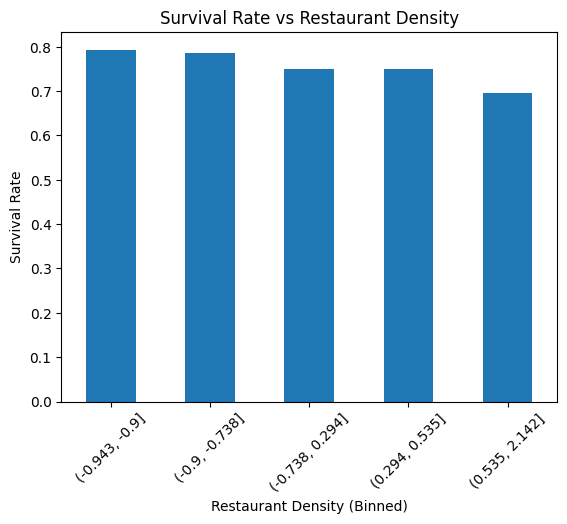

In [130]:
plt.figure()
df["density_bins"] = pd.qcut(df["restaurant_density_city"], q=5)

df.groupby("density_bins")["target"].mean().plot(kind="bar")
plt.title("Survival Rate vs Restaurant Density")
plt.xlabel("Restaurant Density (Binned)")
plt.ylabel("Survival Rate")
plt.xticks(rotation=45)
plt.show()

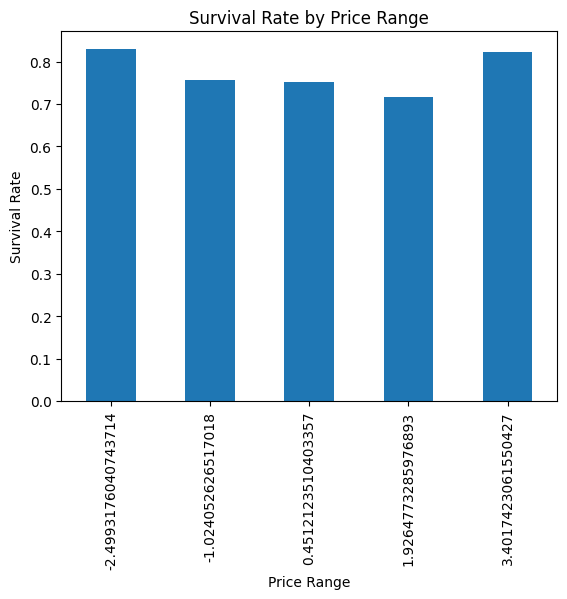

In [131]:
plt.figure()
df.groupby("PriceRange")["target"].mean().plot(kind="bar")
plt.title("Survival Rate by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Survival Rate")
plt.show()

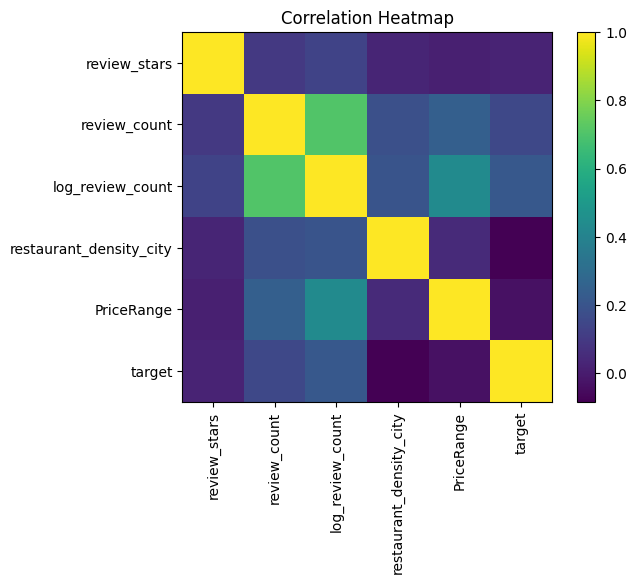

In [132]:
numeric_df = df.select_dtypes(include='number')
plt.figure()
corr = numeric_df.corr()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

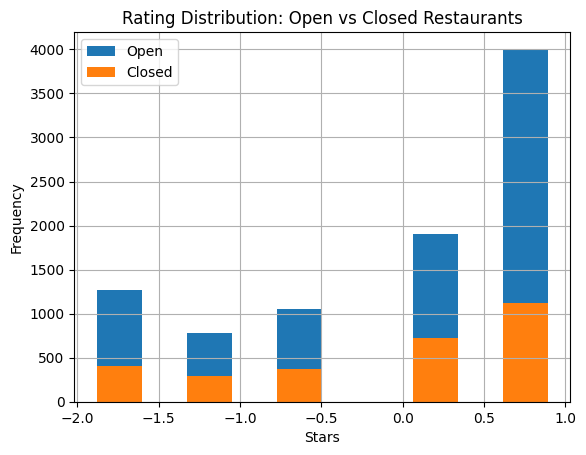

In [133]:
plt.figure()
df[df["target"] == 1]["review_stars"].hist(label="Open")
df[df["target"] == 0]["review_stars"].hist(label="Closed")
plt.legend()
plt.title("Rating Distribution: Open vs Closed Restaurants")
plt.xlabel("Stars")
plt.ylabel("Frequency")
plt.show()

3.6.2 Key Insights

**1. Rating and Survival**: Restaurants with higher ratings tend to have a higher probability of remaining open. Lower-rated restaurants are more frequently associated with closure.

  - Interpretation:
Customer satisfaction is a strong indicator of long-term success.

**2. Review Count and Survival**: Restaurants with a larger number of reviews show higher survival rates, while those with fewer reviews are more likely to close.

  - Interpretation:
Higher customer engagement and popularity contribute to business stability.

**3. Location Impact:** Survival rates vary significantly across different cities, indicating that geographic location plays an important role in restaurant success.

  - Interpretation:
This supports the use of spatial modeling techniques such as Graph Neural Networks to capture location-based effects.

**4. Competition (Restaurant Density):** Restaurant survival varies with the density of nearby restaurants. Areas with high density may indicate either strong market demand or intense competition.

  - Interpretation:
The relationship between competition and survival is complex and requires advanced models to capture.

**5. Price Range:** Mid-range restaurants tend to exhibit higher survival rates compared to very low or very high price ranges.

  - Interpretation:
Pricing strategy influences sustainability and customer reach.

**6. Feature Relationships:** Correlation analysis shows that most features have weak linear relationships with the target variable.

  - Interpretation:
This suggests that restaurant survival depends on non-linear interactions between multiple factors, motivating the use of models such as neural networks and gradient boosting.

3.6.3 Avoid Feature Leakage

**To ensure reliable model performance, the following precautions were taken:**

- The target variable (is_open) was not used as an input feature
- Data was split into training and testing sets before preprocessing
- Scaling and transformations were applied using only the training data
- No future information (e.g., post-closure reviews) was included in feature construction

**Result:**
These steps ensure that the model evaluation reflects real-world predictive performance.